<a href="https://colab.research.google.com/github/NavinkumarD/Sales_Data_Analysis/blob/main/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sales.csv to sales.csv
First 5 rows of data:
        Date       Product    Category  Quantity  Price Region  Unnamed: 6  \
0 2026-01-01    Coffee Mug     Kitchen      10.0    5.0  North         NaN   
1 2026-01-03       Tea Cup     Kitchen      15.0    3.0  South         NaN   
2 2026-01-05      Notebook  Stationery      20.0    2.0   East         NaN   
3 2026-01-07           Pen  Stationery      30.0    1.0   West         NaN   
4 2026-01-10  Water Bottle      Sports       5.0   10.0  North         NaN   

   Unnamed: 7  Unnamed: 8  Unnamed: 9 Unnamed: 10  Total_Sales  
0         NaN         NaN         NaN         NaN         50.0  
1         NaN         NaN         NaN         NaN         45.0  
2         NaN         NaN         NaN         NaN         40.0  
3         NaN         NaN         NaN         NaN         30.0  
4         NaN         NaN         NaN         NaN         50.0  

Summary statistics:
                      Date   Quantity       Price  Unnamed: 6  Unnam

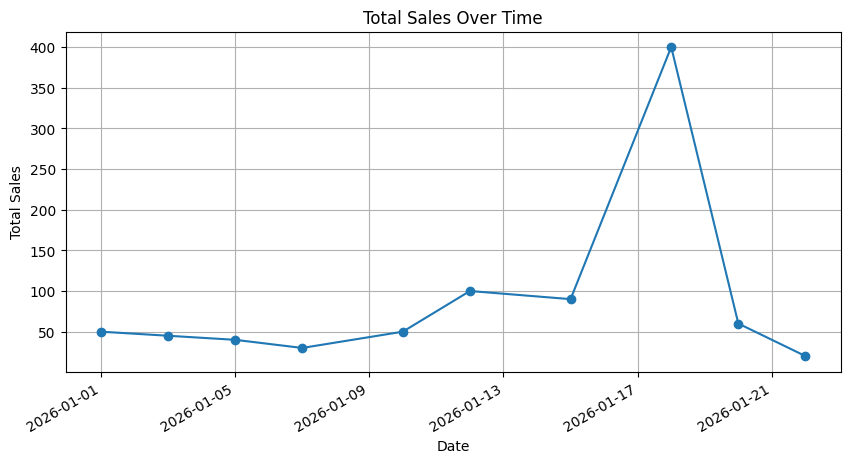

/tmp/ipython-input-3711695617.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


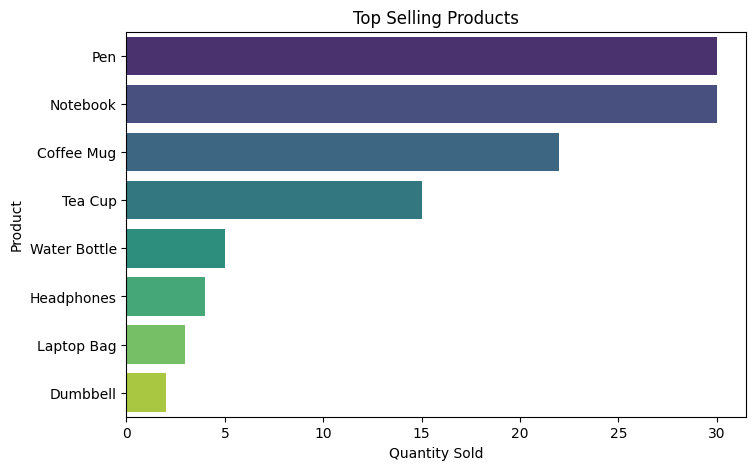

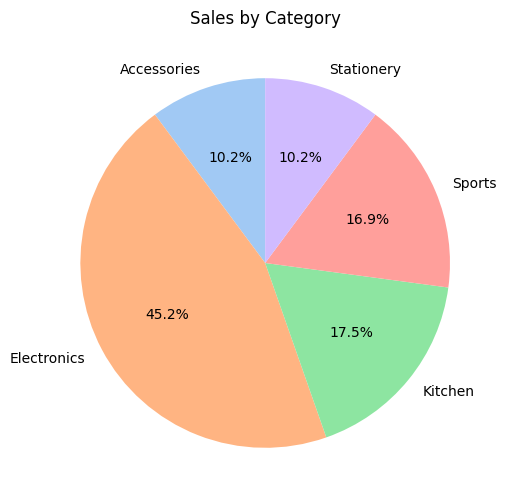

Cleaned dataset saved as sales_cleaned.csv


In [1]:
# -------------------------------
# Sales Data Analysis Project
# -------------------------------

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Upload your CSV file
from google.colab import files
uploaded = files.upload()  # Click "Choose Files" and select your sales CSV

# Step 3: Load dataset (adjust filename if needed)
df = pd.read_csv('sales.csv')  # Or 'sales (1).csv'

# Step 4: Data Cleaning
# Convert Date column to datetime (DD-MM-YYYY format)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Calculate Total_Sales if not already present
df['Total_Sales'] = df['Quantity'] * df['Price']

# Step 5: Quick overview
print("First 5 rows of data:")
print(df.head())

print("\nSummary statistics:")
print(df.describe())

# Step 6: Sales trends over time
plt.figure(figsize=(10,5))
df.groupby('Date')['Total_Sales'].sum().plot(marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# Step 7: Top selling products by quantity
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

# Step 8: Sales by Category (Pie Chart)
category_sales = df.groupby('Category')['Total_Sales'].sum()
plt.figure(figsize=(6,6))
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales by Category')
plt.ylabel('')
plt.show()

# Step 9: Optional - save cleaned dataset
df.to_csv('sales_cleaned.csv', index=False)
print("Cleaned dataset saved as sales_cleaned.csv")
